# Введение
Этот проект-исследование направлен на изучение **MOMA**
(Музей современного искусства, Нью-Йорк) и выявления интересных фактов о современном искусстве.

Задачи:

*   Оценить диапазон работ разных годов
*   Узнать соотношение авторов мужчин и женщин в коллекции по десятилетиям
*   Исследовать количество художников разных национальностей в коллекции
*   Проверить тезис, что искусство становится больше, то есть существует ли зависимость между размером произведения и годом его создания


In [112]:
# Импорт необходимых библиотек
import matplotlib.pyplot as plt  # Основная библиотека для визуализации
import numpy as np                # Работа с числовыми массивами
import pandas as pd               # Работа с табличными данными
import seaborn as sns             # Расширенная библиотека для визуализации
import re
from wordcloud import WordCloud
import math
from matplotlib.patches import Circle, Rectangle
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm

# Игнорирование предупреждений для чистоты вывода
import warnings
warnings.filterwarnings('ignore')

# %matplotlib inline

Я буду использовать следующие базы данных:


1. Художники: https://github.com/MuseumofModernArt/collection
2. Произведения искусства: https://github.com/MuseumofModernArt/collection



In [115]:
artists = pd.read_csv('https://media.githubusercontent.com/media/MuseumofModernArt/collection/refs/heads/main/Artists.csv')
print(f"📊 Загружено {len(artists)} художников")
artists.head()

📊 Загружено 15766 художников


,ConstituentID,DisplayName,ArtistBio,Nationality,Gender,BeginDate,EndDate,Wiki QID,ULAN
0,1,Robert Arneson,"American, 1930–1992",American,male,1930,1992,NaN,NaN
1,2,Doroteo Arnaiz,"Spanish, born 1936",Spanish,male,1936,0,NaN,NaN
2,3,Bill Arnold,"American, born 1941",American,male,1941,0,NaN,NaN
3,4,Charles Arnoldi,"American, born 1946",American,male,1946,0,Q1063584,500027998.0
4,5,Per Arnoldi,"Danish, born 1941",Danish,male,1941,0,NaN,NaN


In [116]:
paintings = pd.read_csv('https://media.githubusercontent.com/media/MuseumofModernArt/collection/refs/heads/main/Artworks.csv')
print(f"📊 Загружено {len(paintings)} работ")
paintings.head()

📊 Загружено 160113 работ


,Title,Artist,ConstituentID,ArtistBio,Nationality,BeginDate,EndDate,Gender,Date,Medium,...,OnView,Circumference (cm),Depth (cm),Diameter (cm),Height (cm),Length (cm),Weight (kg),Width (cm),Seat Height (cm),Duration (sec.)
0,"Ferdinandsbrücke Project, Vienna, Austria (Ele...",Otto Wagner,6210,"(Austrian, 1841–1918)",(Austrian),(1841),(1918),(male),1896,Ink and cut-and-pasted painted pages on paper,...,NaN,NaN,NaN,NaN,48.6000,NaN,NaN,168.9000,NaN,NaN
1,"City of Music, National Superior Conservatory ...",Christian de Portzamparc,7470,"(French, born 1944)",(French),(1944),(0),(male),1987,Paint and colored pencil on print,...,NaN,NaN,NaN,NaN,40.6401,NaN,NaN,29.8451,NaN,NaN
2,"Villa project, outside Vienna, Austria (Elevat...",Emil Hoppe,7605,"(Austrian, 1876–1957)",(Austrian),(1876),(1957),(male),1903,"Graphite, pen, color pencil, ink, and gouache ...",...,NaN,NaN,NaN,NaN,34.3000,NaN,NaN,31.8000,NaN,NaN
3,"The Manhattan Transcripts Project, New York, N...",Bernard Tschumi,7056,"(French and Swiss, born Switzerland 1944)",(),(1944),(0),(male),1980,Photographic reproduction with colored synthet...,...,NaN,NaN,NaN,NaN,50.8000,NaN,NaN,50.8000,NaN,NaN
4,"Villa project, outside Vienna, Austria (Exteri...",Emil Hoppe,7605,"(Austrian, 1876–1957)",(Austrian),(1876),(1957),(male),1903,"Graphite, color pencil, ink, and gouache on tr...",...,NaN,NaN,NaN,NaN,38.4000,NaN,NaN,19.1000,NaN,NaN


# Произведения исскуства

Для выполнения это задачи будем использовать базу данных `paintings`. Сначала построим зависимость количества работ от года с помощью гистограммы и Line plot.


In [119]:
def extract_year(date_str):
    if pd.isna(date_str):
        return np.nan

    try:
        if isinstance(date_str, (int, float)):
            return int(date_str) if 1000 <= date_str <= 2100 else np.nan

        date_str = str(date_str).strip()

        # "1947"
        if re.match(r'^\d{4}$', date_str):
            return int(date_str)

        # "1947-1949" или "1947-49"
        range_match = re.match(r'^(\d{4})[-–](\d{2,4})', date_str)
        if range_match:
            return int(range_match[:2] + range_match[-2:])

        # "1947 (printed 1976)"
        year_match = re.search(r'\b(19|20)\d{2}\b', date_str)
        if year_match:
            return int(year_match.group())

        # "c. 1947" или "1947c"
        approx_match = re.search(r'(?:c\.\s*|c\s+)?(\d{4})c?', date_str, re.IGNORECASE)
        if approx_match:
            return int(approx_match.group(1))

        # "1947, 1949"
        two_years = re.search(r'(\d{4})\s*,\s*\d{4}', date_str)
        if two_years:
            return int(two_years[-4:])

        return np.nan

    except:
        return np.nan

paintings['Year'] = paintings['Date'].apply(extract_year)
total_rows = len(paintings)
valid_years = paintings['Year'].notna().sum()
print(f"Успешно извлечены годы для {valid_years} из {total_rows} работ ({valid_years/total_rows*100:.1f}%)")

Успешно извлечены годы для 133421 из 160113 работ (83.3%)


Максимальный год: 2025


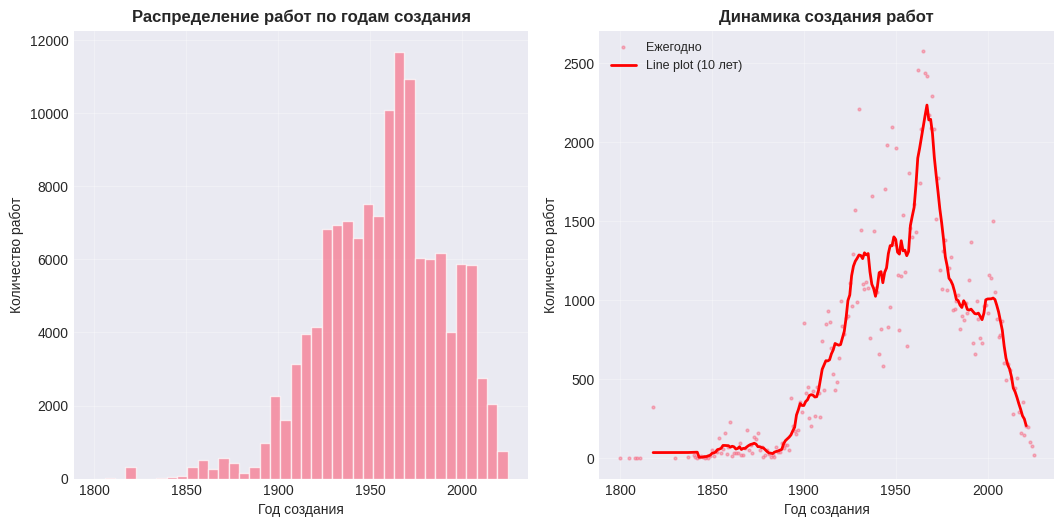

In [120]:
valid_data = paintings[(paintings['Year'] >= 1800) & (paintings['Year'] <= 2025)]
print(f"Максимальный год: {int(valid_data['Year'].max())}")

plt.figure(figsize=(16, 10))

# Гистограмма
plt.subplot(2, 3, 1)
plt.hist(valid_data['Year'], bins=40, edgecolor='white', alpha=0.7)
plt.title('Распределение работ по годам создания', fontsize=12, fontweight='bold')
plt.xlabel('Год создания', fontsize=10)
plt.ylabel('Количество работ', fontsize=10)
plt.grid(True, alpha=0.3)


# Line plot
plt.subplot(2, 3, 2)
year_counts = valid_data['Year'].value_counts().sort_index()

# За 10 лет
window_size = 10
moving_avg = year_counts.rolling(window=window_size, center=True).mean()

plt.plot(year_counts.index, year_counts.values, 'o', markersize=2, alpha=0.5, label='Ежегодно')
plt.plot(moving_avg.index, moving_avg.values, 'r-', linewidth=2,
            label=f'Line plot ({window_size} лет)')
plt.title('Динамика создания работ', fontsize=12, fontweight='bold')
plt.xlabel('Год создания', fontsize=10)
plt.ylabel('Количество работ', fontsize=10)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Наибольшее число работ датируются приблизительно 1970ми. На втором графике можно заметить пики в 1940х и 2000х. Как ни странно, чем ближе к сегодняшнему дню, тем меньше работ.

Теперь проведем анализ соотношения мужчин и женщин по годам. Для этого построим Stream Graph.

Распределение по гендерам:
  male: 102082 работ (85.1%)
  female: 17804 работ (14.9%)


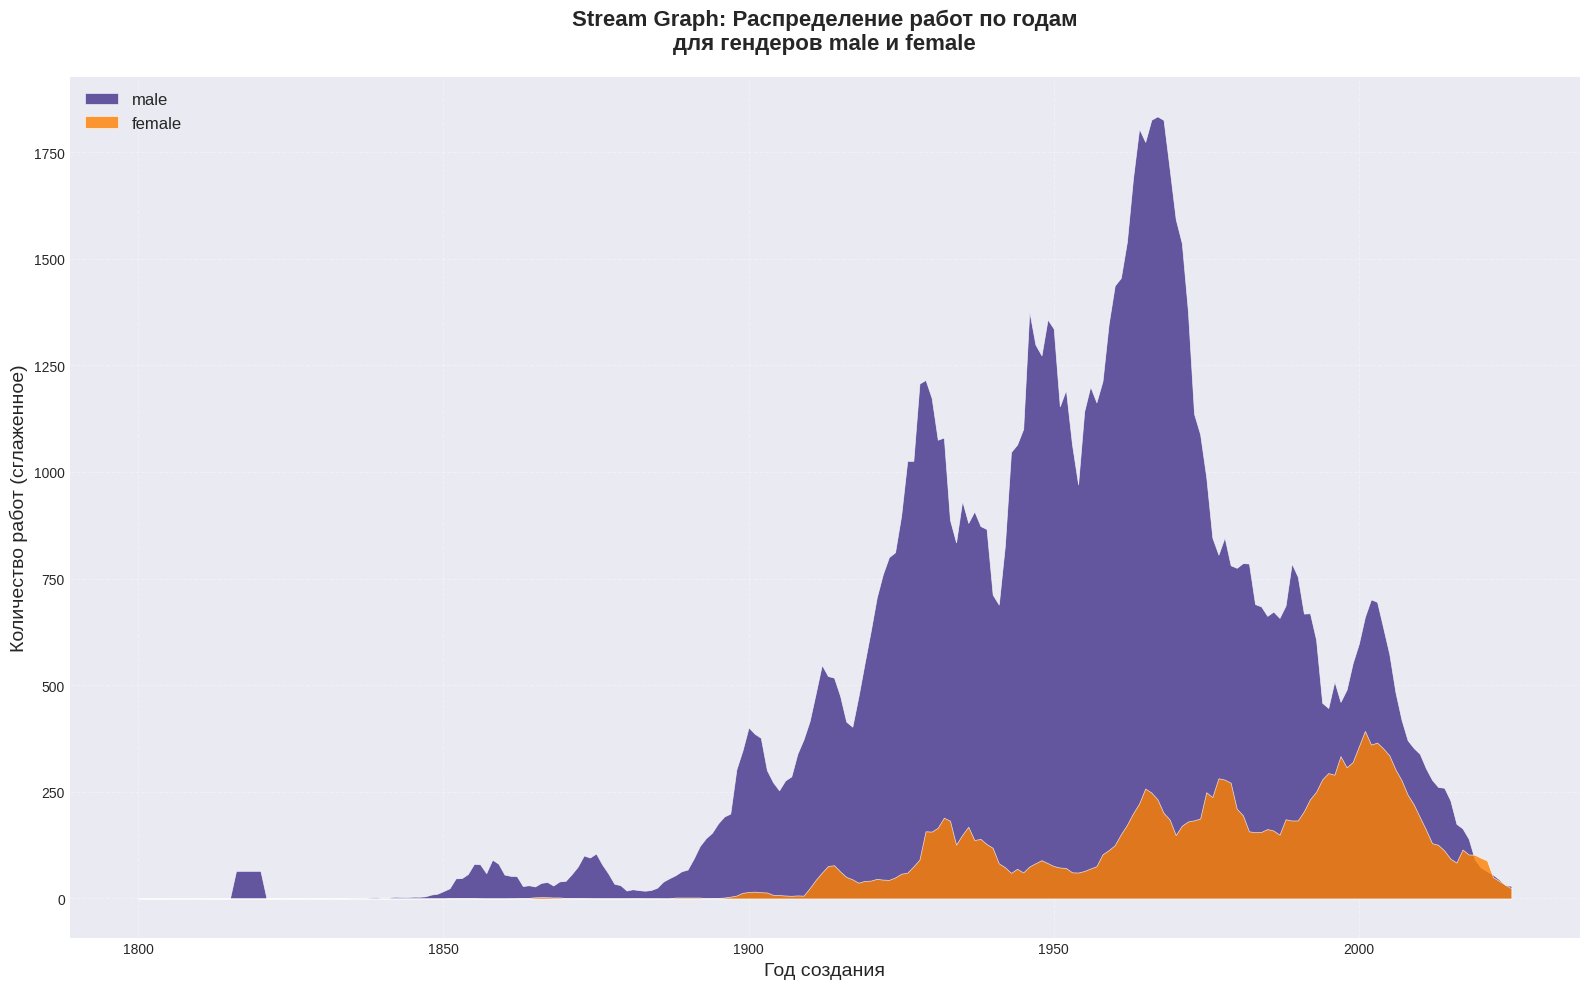

In [121]:
def normalize_gender(gender_str):
    if pd.isna(gender_str):
        return np.nan
    gender_str = str(gender_str).strip().lower()
    if gender_str == '(male)':
        return 'male'
    if gender_str == '(female)':
        return 'female'
    return np.nan


valid_data['Gender_Normalized'] = valid_data['Gender'].apply(normalize_gender)
data_with_gender = valid_data.dropna(subset=['Gender_Normalized']).copy()
gender_counts = data_with_gender['Gender_Normalized'].value_counts()
print("Распределение по гендерам:")
for gender, count in gender_counts.items():
    percentage = count / len(data_with_gender) * 100
    print(f"  {gender}: {count} работ ({percentage:.1f}%)")

gender1, gender2 = 'male', 'female'
stream_data = data_with_gender[data_with_gender['Gender_Normalized'].isin([gender1, gender2])].copy()

# Создаем сводную таблицу: годы × гендеры
yearly_counts = pd.crosstab(stream_data['Year'], stream_data['Gender_Normalized'])
all_years = range(int(stream_data['Year'].min()), int(stream_data['Year'].max()) + 1)
yearly_counts = yearly_counts.reindex(all_years, fill_value=0)

# Применяем сглаживание
window = 5
smoothed = yearly_counts.rolling(window=window, center=True, min_periods=1).mean()

# Stream graph
plt.figure(figsize=(16, 10))

colors = {
            gender1: '#423189',  # фиолетовый
            gender2: '#FF8000'   # оранжевый
        }

# Подготовка данных для stream plot
years = smoothed.index.values

bottom_gender1 = np.zeros(len(years))
top_gender1 = smoothed[gender1].values

bottom_gender2 = np.zeros(len(years))
top_gender2 = smoothed[gender2].values

plt.fill_between(years, bottom_gender1, top_gender1,
                        color=colors[gender1], alpha=0.8,
                        label=gender1, edgecolor='white', linewidth=0.5)

plt.fill_between(years, bottom_gender2, top_gender2,
                        color=colors[gender2], alpha=0.8,
                        label=gender2, edgecolor='white', linewidth=0.5)

plt.title(f'Stream Graph: Распределение работ по годам\nдля гендеров {gender1} и {gender2}',
                 fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Год создания', fontsize=14)
plt.ylabel('Количество работ (сглаженное)', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

По количеству работ женщин-художников самым популярным стал 2000. А также всплеск наблюдается в 70х годах.

Теперь проверим гипотезу про увеличение размеров работ со временем. Для этого построим пиктограмму.

Всего работ: 133415
Работ с определенным размером: 106168 (79.6%)
Анализируем 20 десятилетий


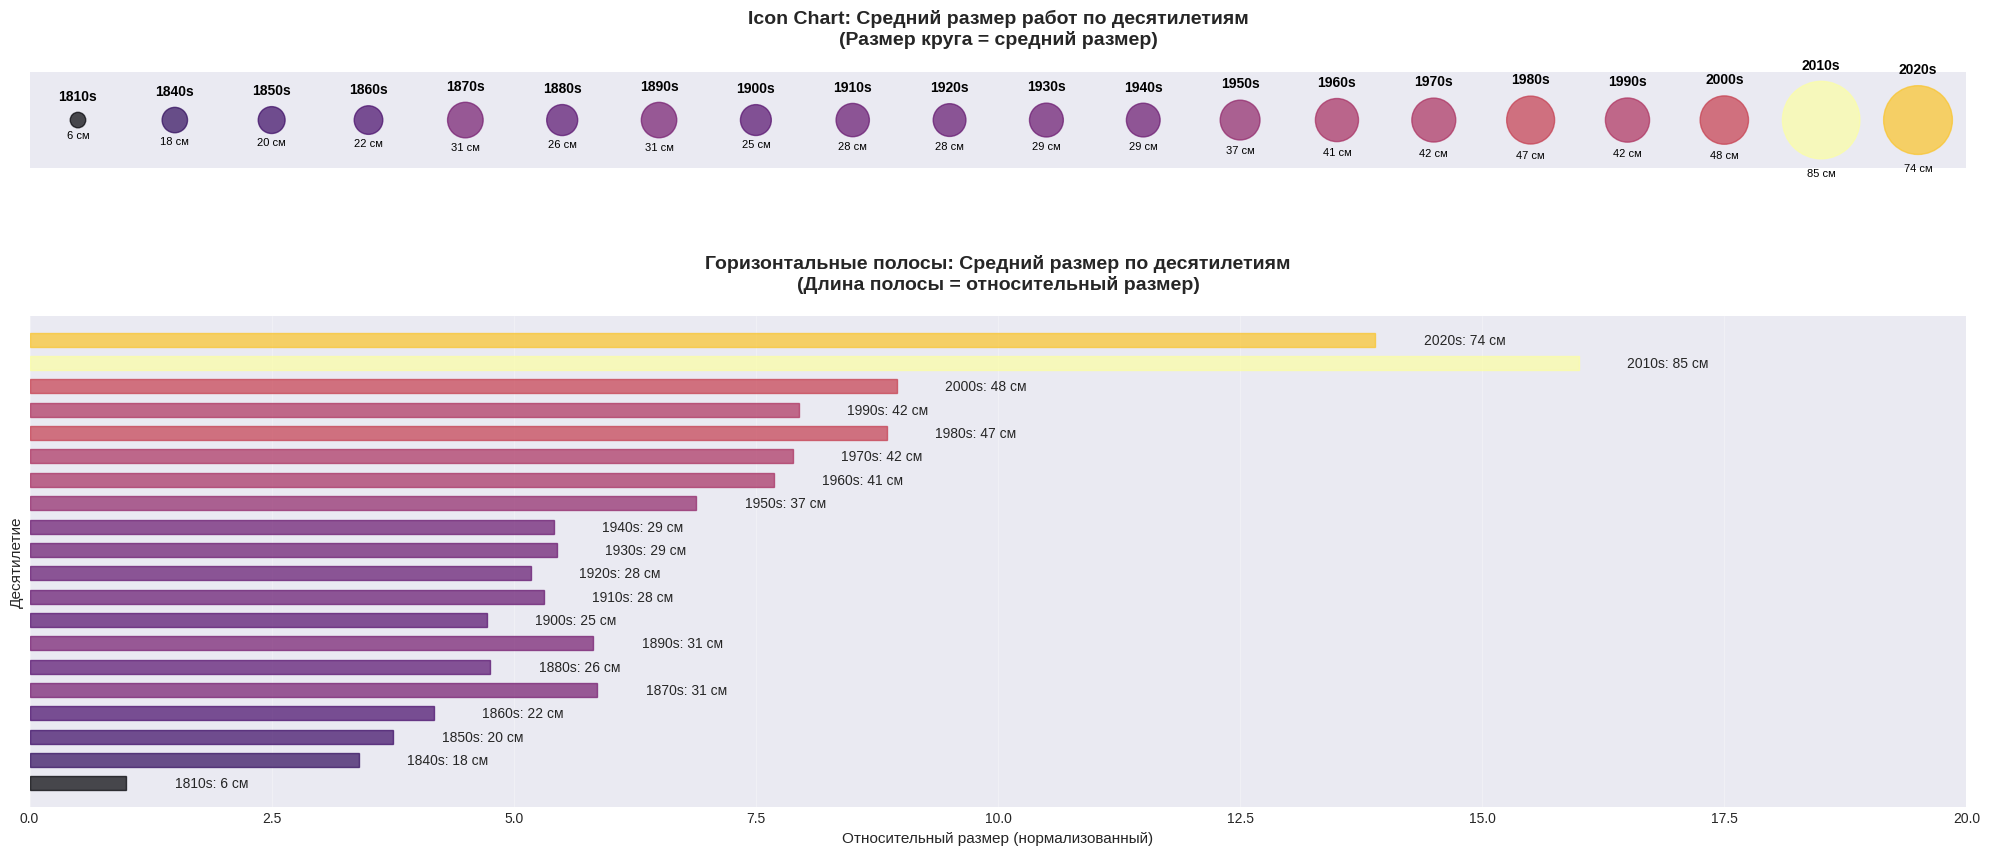

In [122]:
def calculate_size(row):
    try:
        if 'Diameter (cm)' in row.index and pd.notna(row['Diameter (cm)']) and row['Diameter (cm)'] > 0:
            return float(row['Diameter (cm)'])

        if 'Width (cm)' in row.index and 'Height (cm)' in row.index:
            width = row['Width (cm)']
            height = row['Height (cm)']

            if pd.notna(width) and pd.notna(height) and width > 0 and height > 0:
                return np.sqrt(float(width) * float(height))

        return np.nan
    except:
        return np.nan

valid_data['Size'] = valid_data.apply(calculate_size, axis=1)

total_works = len(valid_data)
works_with_size = valid_data['Size'].notna().sum()
print(f"Всего работ: {total_works}")
print(f"Работ с определенным размером: {works_with_size} ({works_with_size/total_works*100:.1f}%)")

if works_with_size > 0:
    valid_data['Decade'] = (valid_data['Year'] // 10) * 10
    size_data = valid_data.dropna(subset=['Size', 'Decade']).copy()

    decade_stats = size_data.groupby('Decade')['Size'].agg(['mean', 'median', 'count']).reset_index()
    decade_stats.columns = ['Decade', 'Mean_Size', 'Median_Size', 'Count']
    decade_stats = decade_stats[decade_stats['Count'] >= 10].sort_values('Decade')

    if len(decade_stats) > 0:
        print(f"Анализируем {len(decade_stats)} десятилетий")

        # ICON CHART
        n_decades = len(decade_stats)

        fig, axes = plt.subplots(2, 1, figsize=(20, 10))
        axes = axes.flatten()

        min_size = decade_stats['Mean_Size'].min()
        max_size = decade_stats['Mean_Size'].max()

        normalized_sizes = (decade_stats['Mean_Size'] - min_size) / (max_size - min_size)

        # Список цветов
        cmap = cm.get_cmap('inferno')
        colors = [cmap(norm_size) for norm_size in normalized_sizes]

        decade_color_dict = {int(row['Decade']): colors[i] for i, (_, row) in enumerate(decade_stats.iterrows())}

        # 1. Круги
        ax1 = axes[0]

        sorted_by_size = decade_stats

        n_cols = 20
        n_rows = 1

        for idx, (_, row) in enumerate(sorted_by_size.iterrows()):
            decade = int(row['Decade'])
            mean_size = row['Mean_Size']
            count = int(row['Count'])

            row_idx = idx // n_cols
            col_idx = idx % n_cols

            size_norm = (mean_size - min_size) / (max_size - min_size) * 0.8 + 0.2
            color = decade_color_dict[decade]
            norm_val = (mean_size - min_size) / (max_size - min_size)

            # Рисуем круг
            circle = Circle((col_idx + 0.5, n_rows - row_idx - 0.5),
                           radius=size_norm * 0.4,
                           color=color,
                           alpha=0.7,
                           edgecolor='white',
                           linewidth=1)
            ax1.add_patch(circle)

            # Десятилетие
            ax1.text(col_idx + 0.5, n_rows - row_idx - 0.5 + size_norm * 0.4 + 0.1,
                    f'{decade}s',
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold',
                    color='black')

            # Размер
            ax1.text(col_idx + 0.5, n_rows - row_idx - 0.5 - size_norm * 0.5,
                    f'{mean_size:.0f} см',
                    ha='center', va='top',
                    fontsize=8,
                    color='black' if norm_val > 0.5 else 'black')

        ax1.set_xlim(0, n_cols)
        ax1.set_ylim(0, n_rows)
        ax1.set_aspect('equal')
        ax1.set_title('Icon Chart: Средний размер работ по десятилетиям\n(Размер круга = средний размер)',
                     fontsize=14, fontweight='bold', pad=20)
        ax1.grid(True, alpha=0.3, linestyle='--')
        ax1.set_xticks([])
        ax1.set_yticks([])


        # 2. Полосы
        ax2 = axes[1]

        decade_stats_sorted = decade_stats.sort_values('Decade')

        y_positions = np.arange(len(decade_stats_sorted))
        bar_heights = 0.6

        for i, (_, row) in enumerate(decade_stats_sorted.iterrows()):
            decade = int(row['Decade'])
            mean_size = row['Mean_Size']

            length = (mean_size - min_size) / (max_size - min_size) * 15 + 1

            color = decade_color_dict[decade]

            rect = Rectangle((0, y_positions[i] - bar_heights/2),
                            length, bar_heights,
                            color=color,
                            alpha=0.7,
                            edgecolor='black',
                            linewidth=1)
            ax2.add_patch(rect)

            ax2.text(length + 0.5, y_positions[i],
                    f'{decade}s: {mean_size:.0f} см',
                    va='center',
                    fontsize=10)

        ax2.set_xlim(0, 20)
        ax2.set_ylim(-1, len(decade_stats_sorted))
        ax2.set_title('Горизонтальные полосы: Средний размер по десятилетиям\n(Длина полосы = относительный размер)',
                     fontsize=14, fontweight='bold', pad=20)
        ax2.set_xlabel('Относительный размер (нормализованный)', fontsize=11)
        ax2.set_ylabel('Десятилетие', fontsize=11)
        ax2.set_yticks([])
        ax2.grid(True, alpha=0.3, axis='x')

        plt.tight_layout()
        plt.show()

# Художники

Для выполнения это задачи будем использовать базу данных `artists`. Создадим Word cloud национальностей.

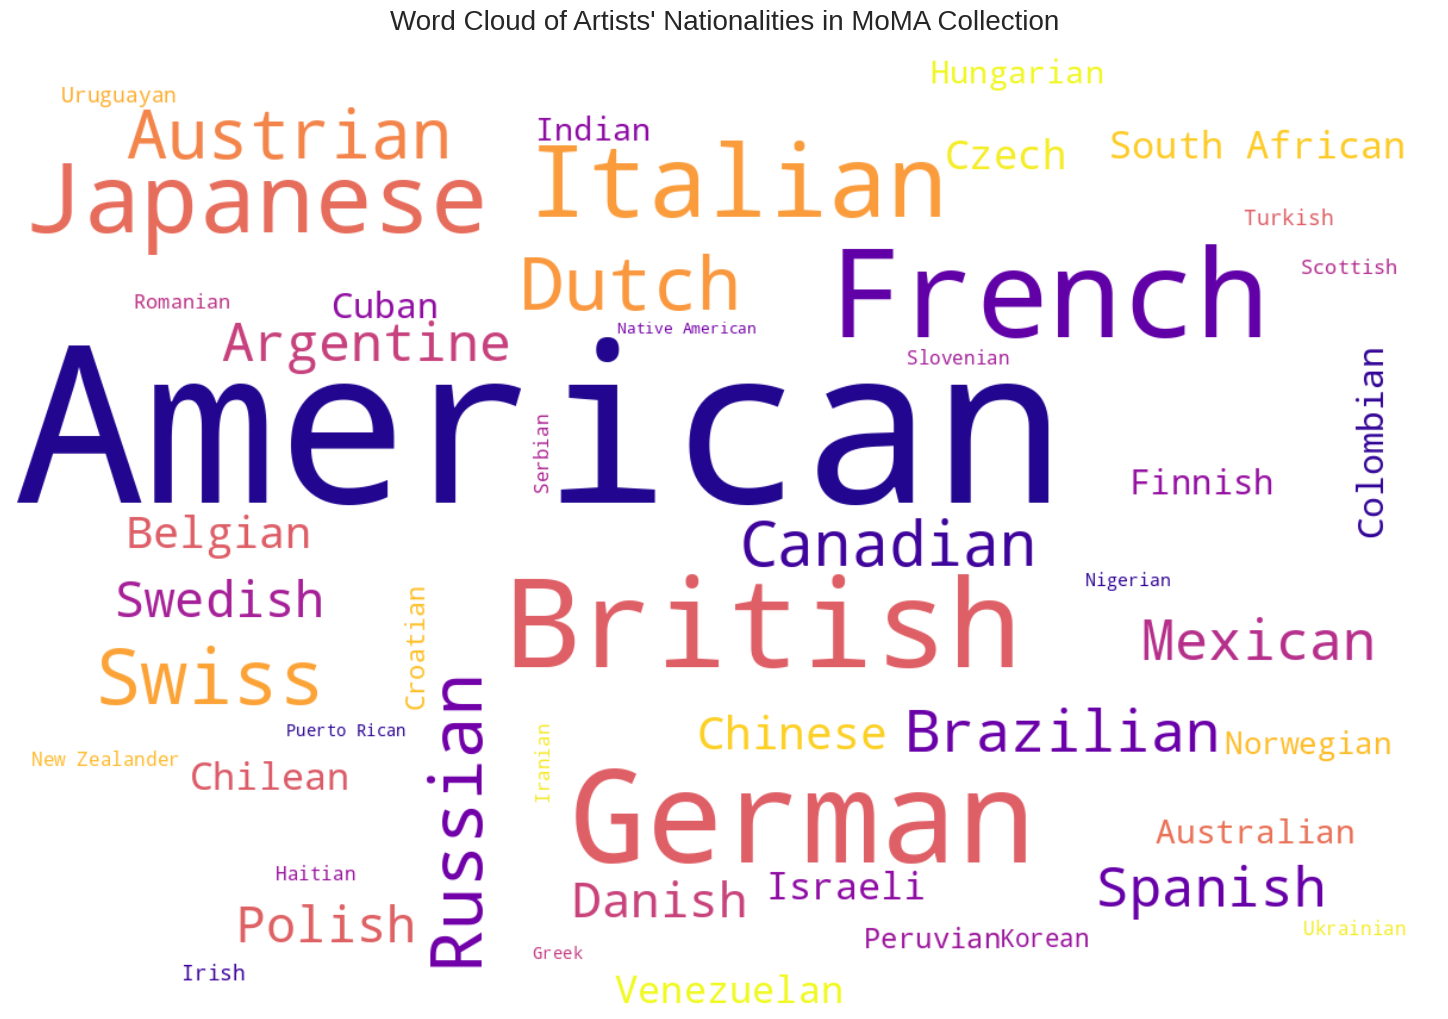

In [117]:
def clean_nationality(text):
    if pd.isna(text):
        return np.nan
    if str(text).strip().lower() == 'nationality unknown':
        return np.nan
    return str(text).strip().title()


artists['Nationality_Clean'] = artists['Nationality'].apply(clean_nationality).dropna()
nationality_counts = artists['Nationality_Clean'].value_counts()

# Word cloud
wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color='white',
    colormap='plasma',
    max_words=50,
    contour_width=1,
    contour_color='steelblue',
    collocations=False
).generate_from_frequencies(nationality_counts)

plt.figure(figsize=(16, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Artists\' Nationalities in MoMA Collection', fontsize=20, pad=20)
plt.tight_layout(pad=0)
plt.show()

Ничего удивительного: наибольшая популярность у американцев в музее в Нью Йорке! 🗽

Теперь создадим Bar Plot для более наглядного сравнения по количеству национальностей.

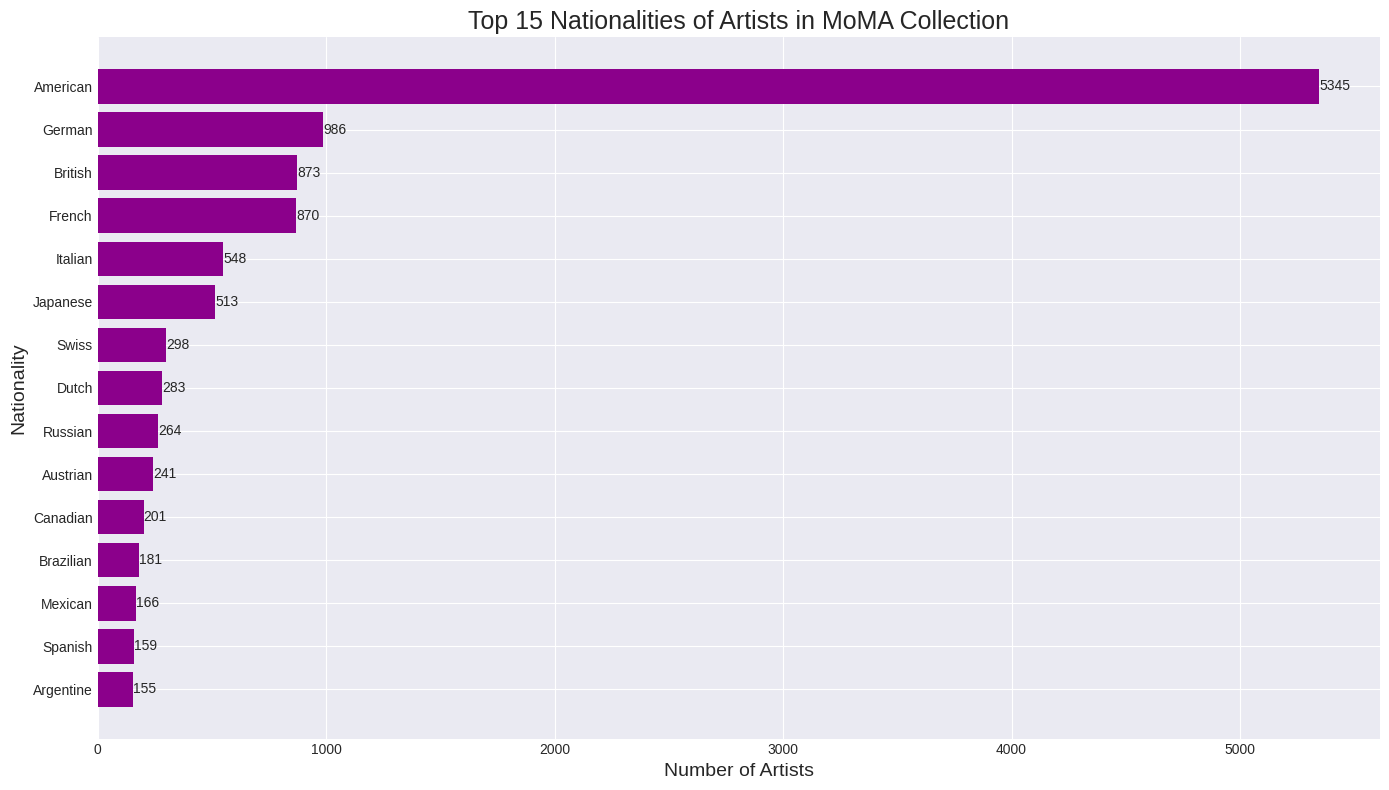

Всего уникальных национальностей: 137

Топ-10 национальностей:
Nationality_Clean
American    5345
German       986
British      873
French       870
Italian      548
Japanese     513
Swiss        298
Dutch        283
Russian      264
Austrian     241
Name: count, dtype: int64

Общее количество художников: 15766


In [118]:
# bar plot
top_n = 15
top_nationalities = nationality_counts.head(top_n)

plt.figure(figsize=(14, 8),)
bars = plt.barh(top_nationalities.index, top_nationalities.values, color='#8B008B')
plt.xlabel('Number of Artists', fontsize=14)
plt.ylabel('Nationality', fontsize=14)
plt.title(f'Top {top_n} Nationalities of Artists in MoMA Collection', fontsize=18)
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


print(f"Всего уникальных национальностей: {len(nationality_counts)}")
print(f"\nТоп-10 национальностей:")
print(nationality_counts.head(10))
print(f"\nОбщее количество художников: {len(artists)}")

Теперь рассмотрим из каких стран